# 0.0 Imports

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns
import inflection

from sklearn import metrics as mt
from matplotlib import pyplot as plt
from IPython.display    import HTML
from ydata_profiling import ProfileReport
from sklearn.model_selection import train_test_split, cross_validate, TunedThresholdClassifierCV
from sklearn            import ensemble             as en
from sklearn            import linear_model         as lm

## 0.1 Helper Functions

In [5]:
def jupyter_settings():
    %matplotlib inline

    plt.style.use( 'bmh' )
    plt.rcParams['figure.figsize'] = [25, 12]
    plt.rcParams['font.size'] = 24

    display( HTML( '<style>.container { width:100% !important; }</style>') )
    pd.options.display.max_columns = None
    pd.options.display.max_rows = None
    pd.set_option( 'display.expand_frame_repr', False )

    sns.set()

jupyter_settings()

## 0.2 Loading Data

In [6]:
df_raw = pd.read_csv('../data/raw/PS_20174392719_1491204439457_log.csv', low_memory=False)

In [7]:
df_raw.sample()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
5782834,400,TRANSFER,61708.53,C1333667874,0.0,0.0,C102489047,2727723.69,2789432.22,0,0


# 1.0 Descrição dos dados

In [8]:
df1 = df_raw.copy()

## 1.1 Rename Columns

In [9]:
df1.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [10]:
cols_old = ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud']

snakecase = lambda x: inflection.underscore( x )

cols_new = list (map (snakecase, cols_old))


df1.columns = cols_new

## 1.2 Data Dimensions

In [11]:
print('Number of Rows: {}'.format(df1.shape[0]))
print('Number of Columns: {}'.format(df1.shape[1]))

Number of Rows: 6362620
Number of Columns: 11


## 1.3 Data Types

In [12]:
df1.dtypes

step                  int64
type                 object
amount              float64
name_orig            object
oldbalance_org      float64
newbalance_orig     float64
name_dest            object
oldbalance_dest     float64
newbalance_dest     float64
is_fraud              int64
is_flagged_fraud      int64
dtype: object

## 1.4 Check NA

In [13]:
df1.isna().sum()

step                0
type                0
amount              0
name_orig           0
oldbalance_org      0
newbalance_orig     0
name_dest           0
oldbalance_dest     0
newbalance_dest     0
is_fraud            0
is_flagged_fraud    0
dtype: int64

## 1.5 Descriptive Statistical

In [14]:
# profile = ProfileReport(df1)
# profile.to_file('../reports/raw_data_report.html')

In [15]:
num_attributes = df1.select_dtypes( include=['int64', 'float64'])
cat_attributes = df1.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

In [16]:
cat_attributes.sample(5)

,type,name_orig,name_dest
53821,PAYMENT,C1694999326,M2018579411
2650921,CASH_IN,C1835254035,C674664844
5279025,CASH_IN,C1917858061,C56539997
2980904,PAYMENT,C329019208,M396709453
5979945,TRANSFER,C1460269070,C1768033286


### 1.5.1 Numerical Attributes

In [17]:
# Central Tendency - mean, median

ct1 = pd.DataFrame (num_attributes.apply(np.mean)).T
ct2 = pd.DataFrame (num_attributes.apply(np.median)).T

# Dispersion - std, min, max, range, skew, kurtosis

d1 = pd.DataFrame (num_attributes.apply(np.std)).T
d2 = pd.DataFrame (num_attributes.apply(min)).T
d3 = pd.DataFrame (num_attributes.apply(max)).T
d4= pd.DataFrame (num_attributes.apply(lambda x: x.max() - x.min())).T
d5= pd.DataFrame (num_attributes.apply(lambda x: x.skew())).T
d6= pd.DataFrame (num_attributes.apply(lambda x: x.kurtosis())).T

# concatenate
m = pd.concat([d2 ,d3 ,d4 , ct1 ,ct2 , d1 , d5 , d6]).T.reset_index()
m. columns = ['attributes', 'min', 'max', 'range', 'mean', 'median', 'std', 'skew', 'kurtosis' ]

m

,attributes,min,max,range,mean,median,std,skew,kurtosis
0,step,1.0,7.430000e+02,7.420000e+02,2.433972e+02,239.000,1.423320e+02,0.375177,0.329071
1,amount,0.0,9.244552e+07,9.244552e+07,1.798619e+05,74871.940,6.038582e+05,30.993949,1797.956705
2,oldbalance_org,0.0,5.958504e+07,5.958504e+07,8.338831e+05,14208.000,2.888242e+06,5.249136,32.964879
3,newbalance_orig,0.0,4.958504e+07,4.958504e+07,8.551137e+05,0.000,2.924048e+06,5.176884,32.066985
4,oldbalance_dest,0.0,3.560159e+08,3.560159e+08,1.100702e+06,132705.665,3.399180e+06,19.921758,948.674125
5,newbalance_dest,0.0,3.561793e+08,3.561793e+08,1.224996e+06,214661.440,3.674129e+06,19.352302,862.156508
6,is_fraud,0.0,1.000000e+00,1.000000e+00,1.290820e-03,0.000,3.590479e-02,27.779538,769.702982
7,is_flagged_fraud,0.0,1.000000e+00,1.000000e+00,2.514687e-06,0.000,1.585775e-03,630.603629,397659.062500


### 1.5.2 Categorical Attributes

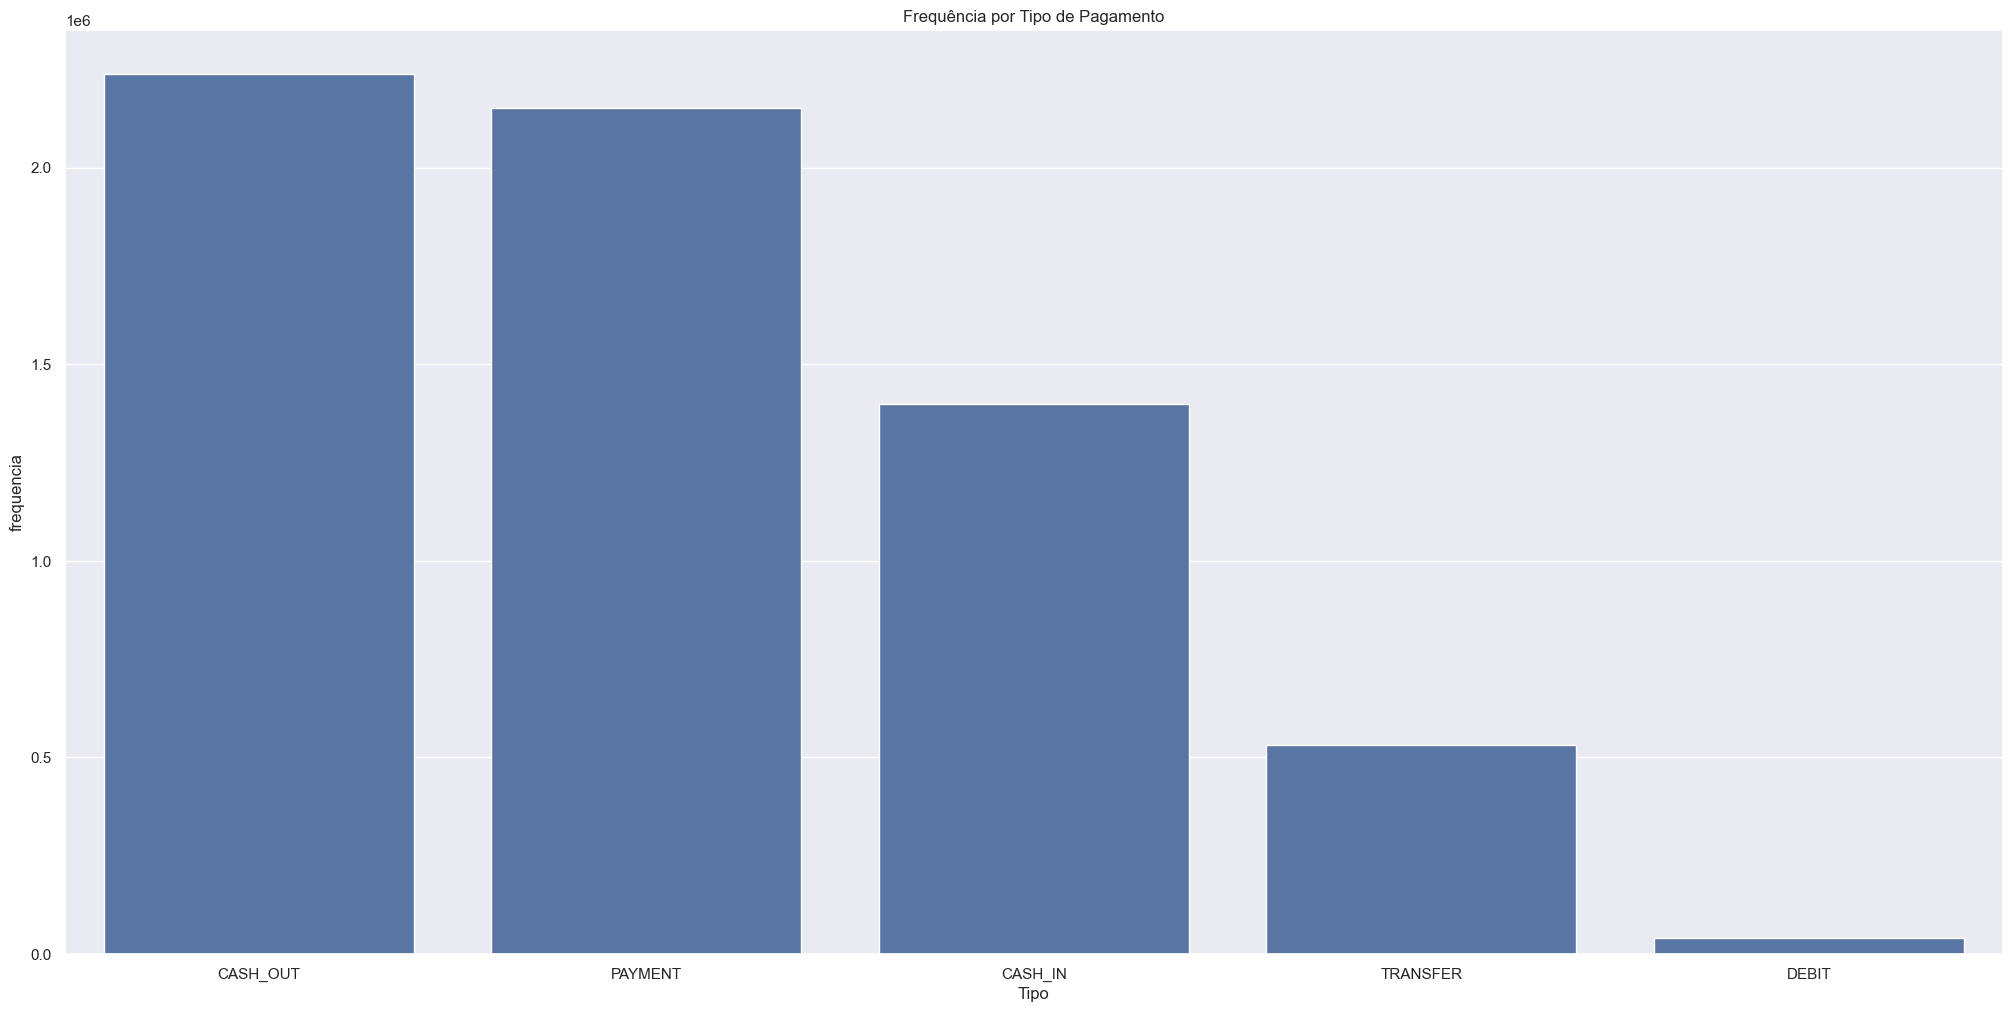

In [18]:
contagem = df1['type'].value_counts().reset_index()
contagem.columns = ['Tipo', 'frequencia']

# Gráfico de barras
sns.barplot(data=contagem, x='Tipo', y='frequencia')
plt.title('Frequência por Tipo de Pagamento')
plt.show()

# 2.0 Feature Engineering

In [19]:
df2 = df1.copy()

In [20]:
def period(h):
    if 5 <= h < 12:
        return 'Morning'
    elif 12 <= h < 18:
        return 'Afternoon'
    elif 18 <= h < 24:
        return 'Evening'
    else:
        return 'Night'

In [21]:
# dia

df2['day'] = (df2['step'] // 24) + 1

# hora 

df2['hora'] = df2['step'] % 24

# periodo do dia

df2['period_of_day'] = df2['hora'].apply(period)

In [22]:
df_aux_fraud1 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Morning')]
df_aux_fraud2 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Afternoon')]
df_aux_fraud3 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Evening')]
df_aux_fraud4 = df2[(df2['is_fraud'] == 1) & (df2['period_of_day'] == 'Night')]

In [23]:
print(f"Fraudes no periodo da manha: {df_aux_fraud1.shape[0]}")
print(f"Fraudes no periodo da tarde: {df_aux_fraud2.shape[0]}")
print(f"Fraudes no periodo da noite: {df_aux_fraud3.shape[0]}")
print(f"Fraudes no periodo da madrugada: {df_aux_fraud4.shape[0]}")

Fraudes no periodo da manha: 2460
Fraudes no periodo da tarde: 2077
Fraudes no periodo da noite: 2046
Fraudes no periodo da madrugada: 1630


# 3.0 Filtragem de Variáveis

In [24]:
df3 = df2.copy()

In [25]:
df3.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
5261928,372,TRANSFER,707644.37,C2039332723,21248.00,0.00,C1547765951,13937.37,721581.75,0,0,16,12,Afternoon
1110814,130,PAYMENT,27040.02,C502707292,12292.00,0.00,M95496149,0.00,0.00,0,0,6,10,Morning
1998594,179,PAYMENT,4282.01,C1866292538,0.00,0.00,M1291457163,0.00,0.00,0,0,8,11,Morning
1686378,159,CASH_OUT,202388.63,C839941194,2742.00,0.00,C2119052772,465417.39,667806.01,0,0,7,15,Afternoon
2435790,203,PAYMENT,5959.00,C2133671179,64853.98,58894.97,M1613822655,0.00,0.00,0,0,9,11,Morning


In [26]:
# Não existe nenhum cliente de origem do tipo Merchant
df_aux2 = df3[df3['name_dest'].str.contains(r'^M', na=False)]

In [27]:
# Não existe nenhuma transição de Merchant classificada como fraude
df_aux2[df_aux2['is_fraud'] == 1].shape

(0, 14)

In [28]:
df_aux = df3[df3['amount'] > 9000000]

In [29]:
df_aux.shape

(6335, 14)

In [30]:
df3_filtered = df3[(~df3['name_dest'].str.contains(r'^M', na=False)) & (df3['amount'] <= 8999999) ]

In [31]:
df3_filtered.shape

(4204790, 14)

In [32]:
num_attributes = df3_filtered.select_dtypes( include=['int64', 'float64'])
cat_attributes = df3_filtered.select_dtypes( exclude=['int64', 'float64', 'datetime64[ns]'])

# 4.0 Análise Exploratória de Dados

In [33]:
df4 = df3_filtered.copy()

## 4.1 Análise Univariada

### 4.1.1 Response Variable

In [34]:
df_valid = df4[df4['is_fraud'] == 0]
df_fraud = df4[df4['is_fraud'] == 1]
df_flagged_fraud = df4[df4['is_flagged_fraud'] == 1] 


print(f'Quantidade de transações válidas: {df_valid.shape[0]}')
print(f'Quantidade de transações fraudulentas: {df_fraud.shape[0]}')
print(f'Quantidade de transações com flag de fraudulentas: {df_flagged_fraud.shape[0]}')

Quantidade de transações válidas: 4196921
Quantidade de transações fraudulentas: 7869
Quantidade de transações com flag de fraudulentas: 12


In [35]:
df_fraud['amount'].max()

np.float64(8994286.69)

In [36]:
df_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
6262140,610,TRANSFER,646676.42,C1136893398,646676.42,0.0,C850364228,0.0,0.00,1,0,26,10,Morning
1511356,150,TRANSFER,119454.86,C1944439526,119454.86,0.0,C525813177,0.0,0.00,1,0,7,6,Morning
1030361,59,TRANSFER,21174.45,C1690317775,21174.45,0.0,C1829927547,0.0,0.00,1,0,3,11,Morning
4105314,302,TRANSFER,1788729.73,C1477176067,1788729.73,0.0,C78352329,0.0,0.00,1,0,13,14,Afternoon
6174267,564,TRANSFER,2472250.47,C577087580,2472250.47,0.0,C660528098,0.0,0.00,1,0,24,12,Afternoon
576348,30,TRANSFER,109401.88,C2037269206,109401.88,0.0,C337579043,0.0,0.00,1,0,2,6,Morning
5065626,354,CASH_OUT,66550.00,C550781139,66550.00,0.0,C335413710,0.0,66550.00,1,0,15,18,Evening
6296127,672,TRANSFER,330756.72,C2036720607,330756.72,0.0,C2048695496,0.0,0.00,1,0,29,0,Night
6019720,457,TRANSFER,145482.09,C1089341002,145482.09,0.0,C1168895160,0.0,0.00,1,0,20,1,Night
6062098,502,CASH_OUT,66066.73,C1566921402,66066.73,0.0,C1640218672,0.0,66066.73,1,0,21,22,Evening


In [37]:
# Para ter uma flag de fraud é quando a transação é maior que 200k
df_flagged_fraud.sample(10)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
6205439,586,TRANSFER,353874.22,C1684585475,353874.22,353874.22,C1770418982,0.0,0.0,1,1,25,10,Morning
3760288,279,TRANSFER,536624.41,C1035541766,536624.41,536624.41,C1100697970,0.0,0.0,1,1,12,15,Afternoon
6362584,741,TRANSFER,5674547.89,C992223106,5674547.89,5674547.89,C1366804249,0.0,0.0,1,1,31,21,Evening
6281484,646,TRANSFER,399045.08,C724693370,10399045.08,10399045.08,C1909486199,0.0,0.0,1,1,27,22,Evening
2736446,212,TRANSFER,4953893.08,C728984460,4953893.08,4953893.08,C639921569,0.0,0.0,1,1,9,20,Evening
6168499,554,TRANSFER,3576297.10,C193696150,3576297.10,3576297.10,C484597480,0.0,0.0,1,1,24,2,Night
6296014,671,TRANSFER,3441041.46,C917414431,3441041.46,3441041.46,C1082139865,0.0,0.0,1,1,28,23,Evening
6266413,617,TRANSFER,2542664.27,C786455622,2542664.27,2542664.27,C661958277,0.0,0.0,1,1,26,17,Afternoon
3247297,250,TRANSFER,1343002.08,C1100582606,1343002.08,1343002.08,C1147517658,0.0,0.0,1,1,11,10,Morning
6351225,702,TRANSFER,3171085.59,C1892216157,3171085.59,3171085.59,C1308068787,0.0,0.0,1,1,30,6,Morning


In [38]:
df_test = df4[df4['amount'] >= 200000]

In [39]:
df_test.sample(5)

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
1022636,47,TRANSFER,259117.13,C305553159,172572.00,0.00,C743434331,0.00,259117.13,0,0,2,23,Evening
3315353,252,CASH_IN,624173.95,C1273426084,5283229.33,5907403.27,C1847104476,11394624.59,10770450.65,0,0,11,12,Afternoon
3913943,284,TRANSFER,1044392.11,C413552259,0.00,0.00,C349507340,1291586.39,2335978.50,0,0,12,20,Evening
2681629,210,TRANSFER,790714.04,C126215794,0.00,0.00,C440182566,1034067.71,1824781.76,0,0,9,18,Evening
232817,14,TRANSFER,650763.22,C748180975,0.00,0.00,C1712828314,1489395.30,1975138.97,0,0,1,14,Afternoon


### 4.1.2 Numerical Attributes

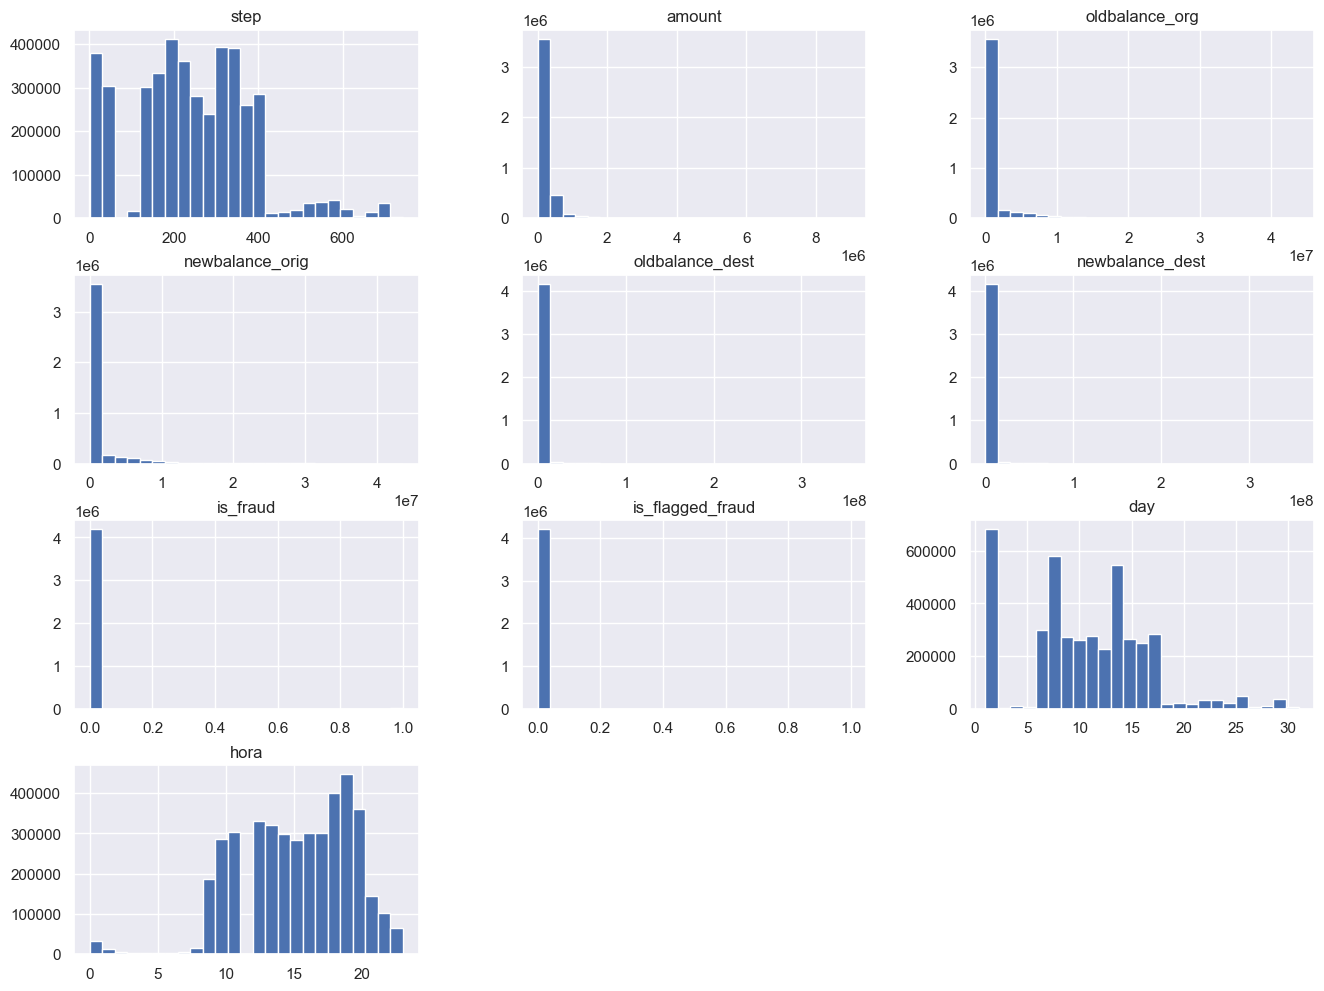

In [40]:
num_attributes.hist(bins= 25, figsize=(16,12));

### 4.1.2 Categorical Variables

<Axes: xlabel='count', ylabel='type'>

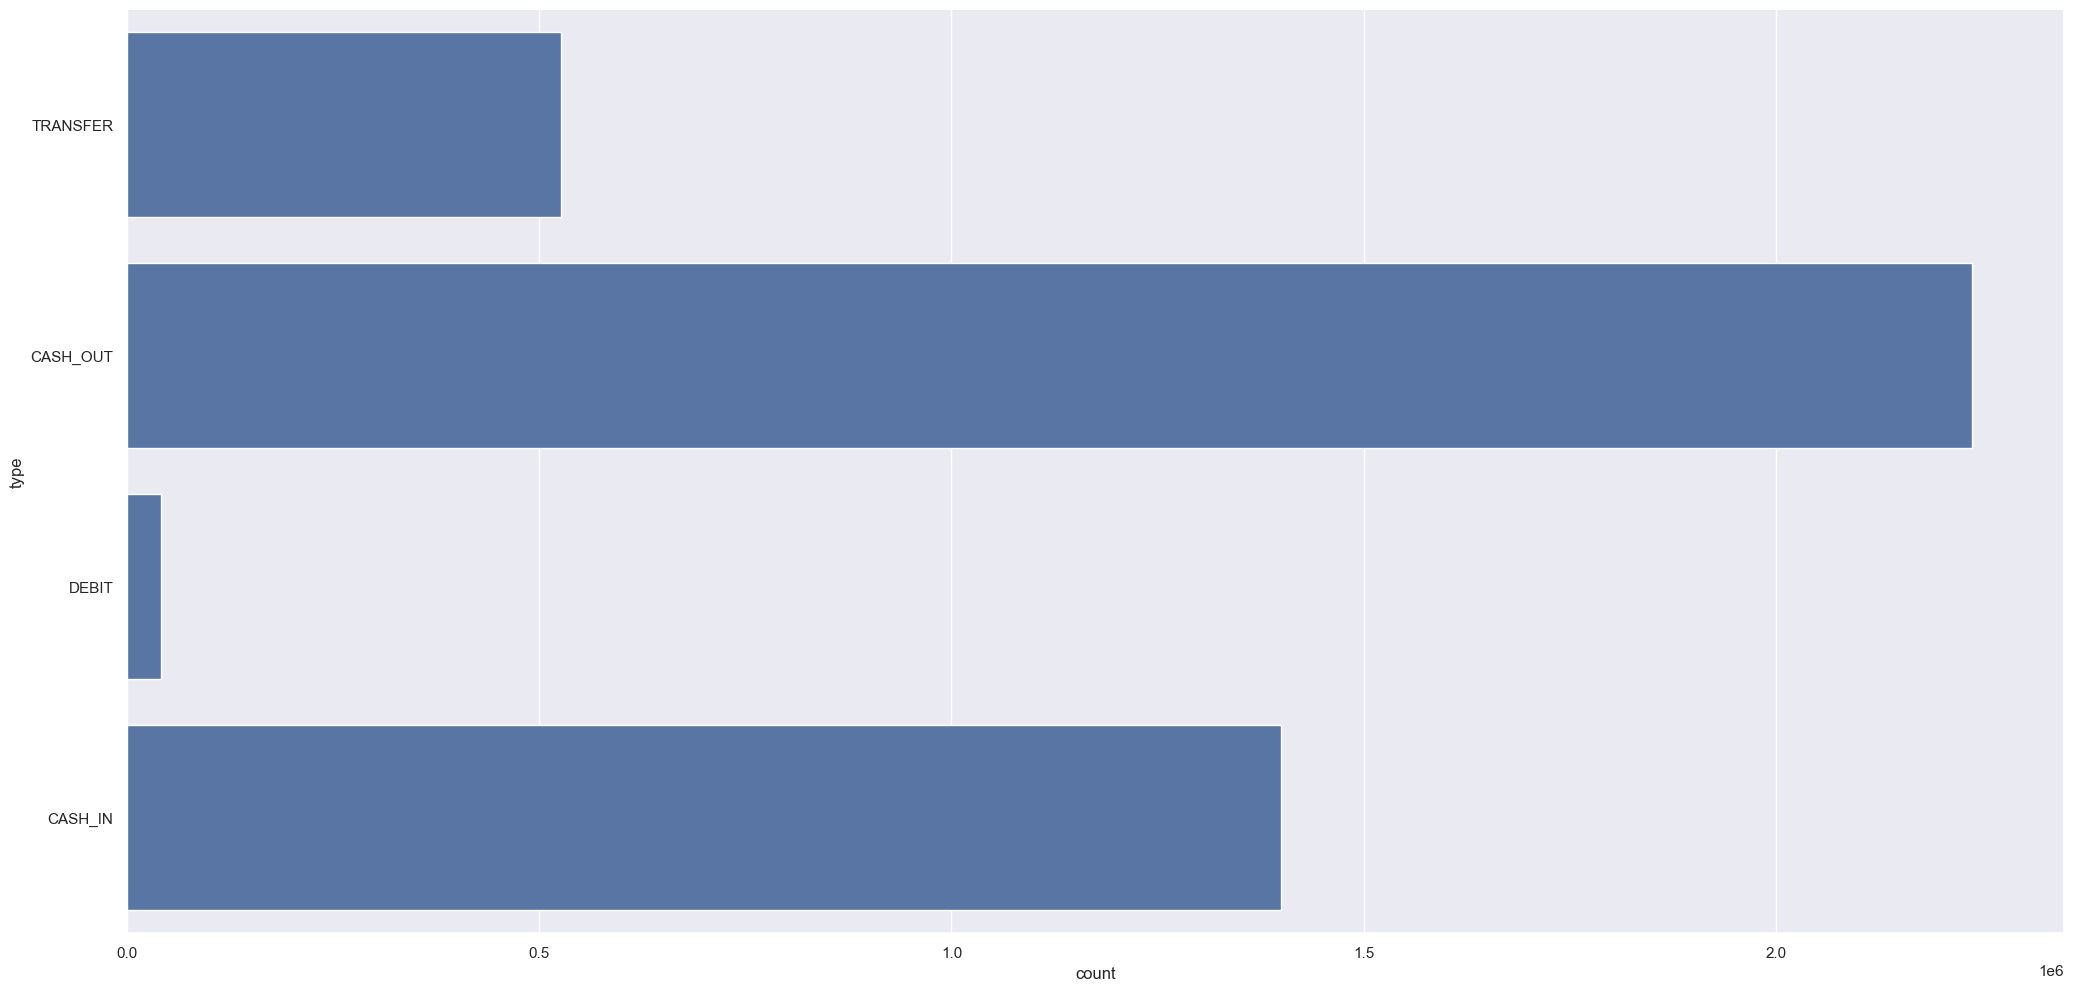

In [41]:
sns.countplot (df4['type'])

## 4.2 Analise Bivariada

In [42]:
df4.columns

Index(['step', 'type', 'amount', 'name_orig', 'oldbalance_org',
       'newbalance_orig', 'name_dest', 'oldbalance_dest', 'newbalance_dest',
       'is_fraud', 'is_flagged_fraud', 'day', 'hora', 'period_of_day'],
      dtype='object')

<Axes: xlabel='type', ylabel='is_fraud'>

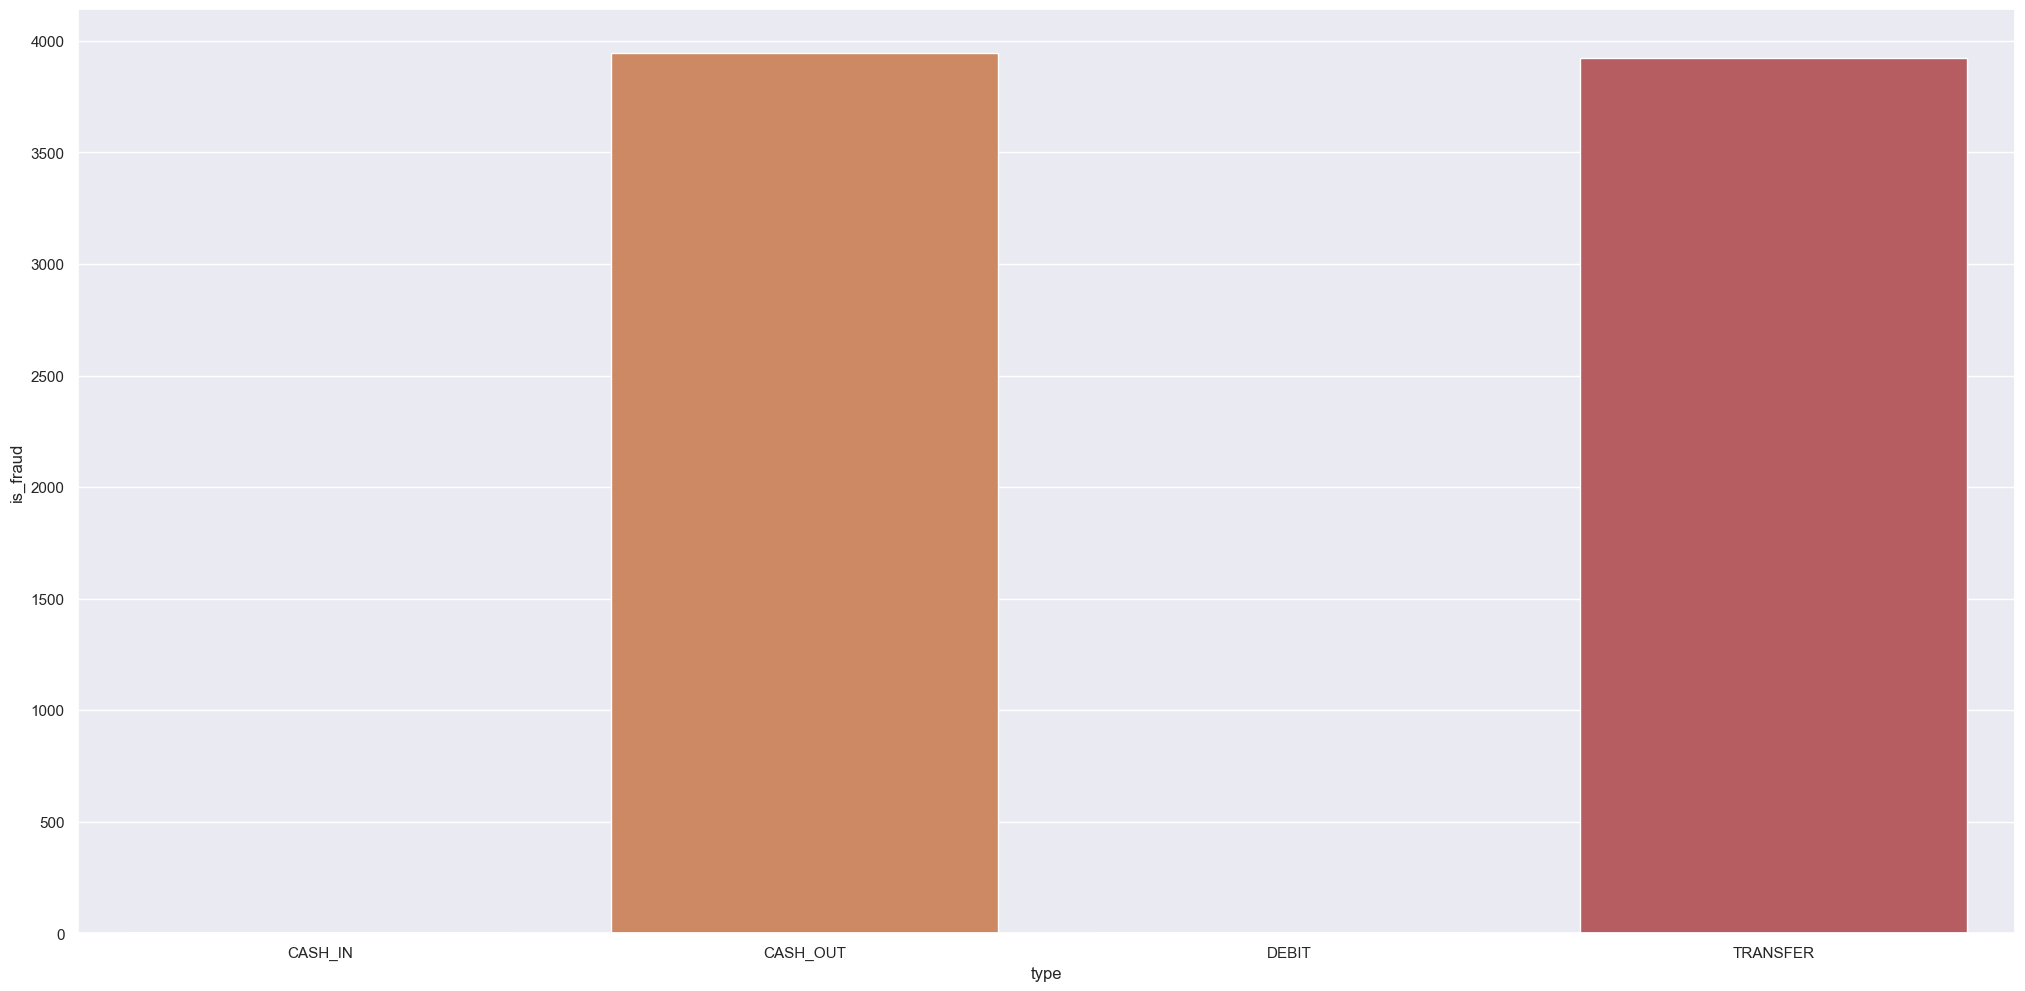

In [43]:
# Tipos de Transações que mais são fraudes

aux1 = df4[['type', 'is_fraud']].groupby('type').sum().reset_index()

sns.barplot( x='type', y='is_fraud', data=aux1, hue='type')

<Axes: xlabel='period_of_day', ylabel='is_fraud'>

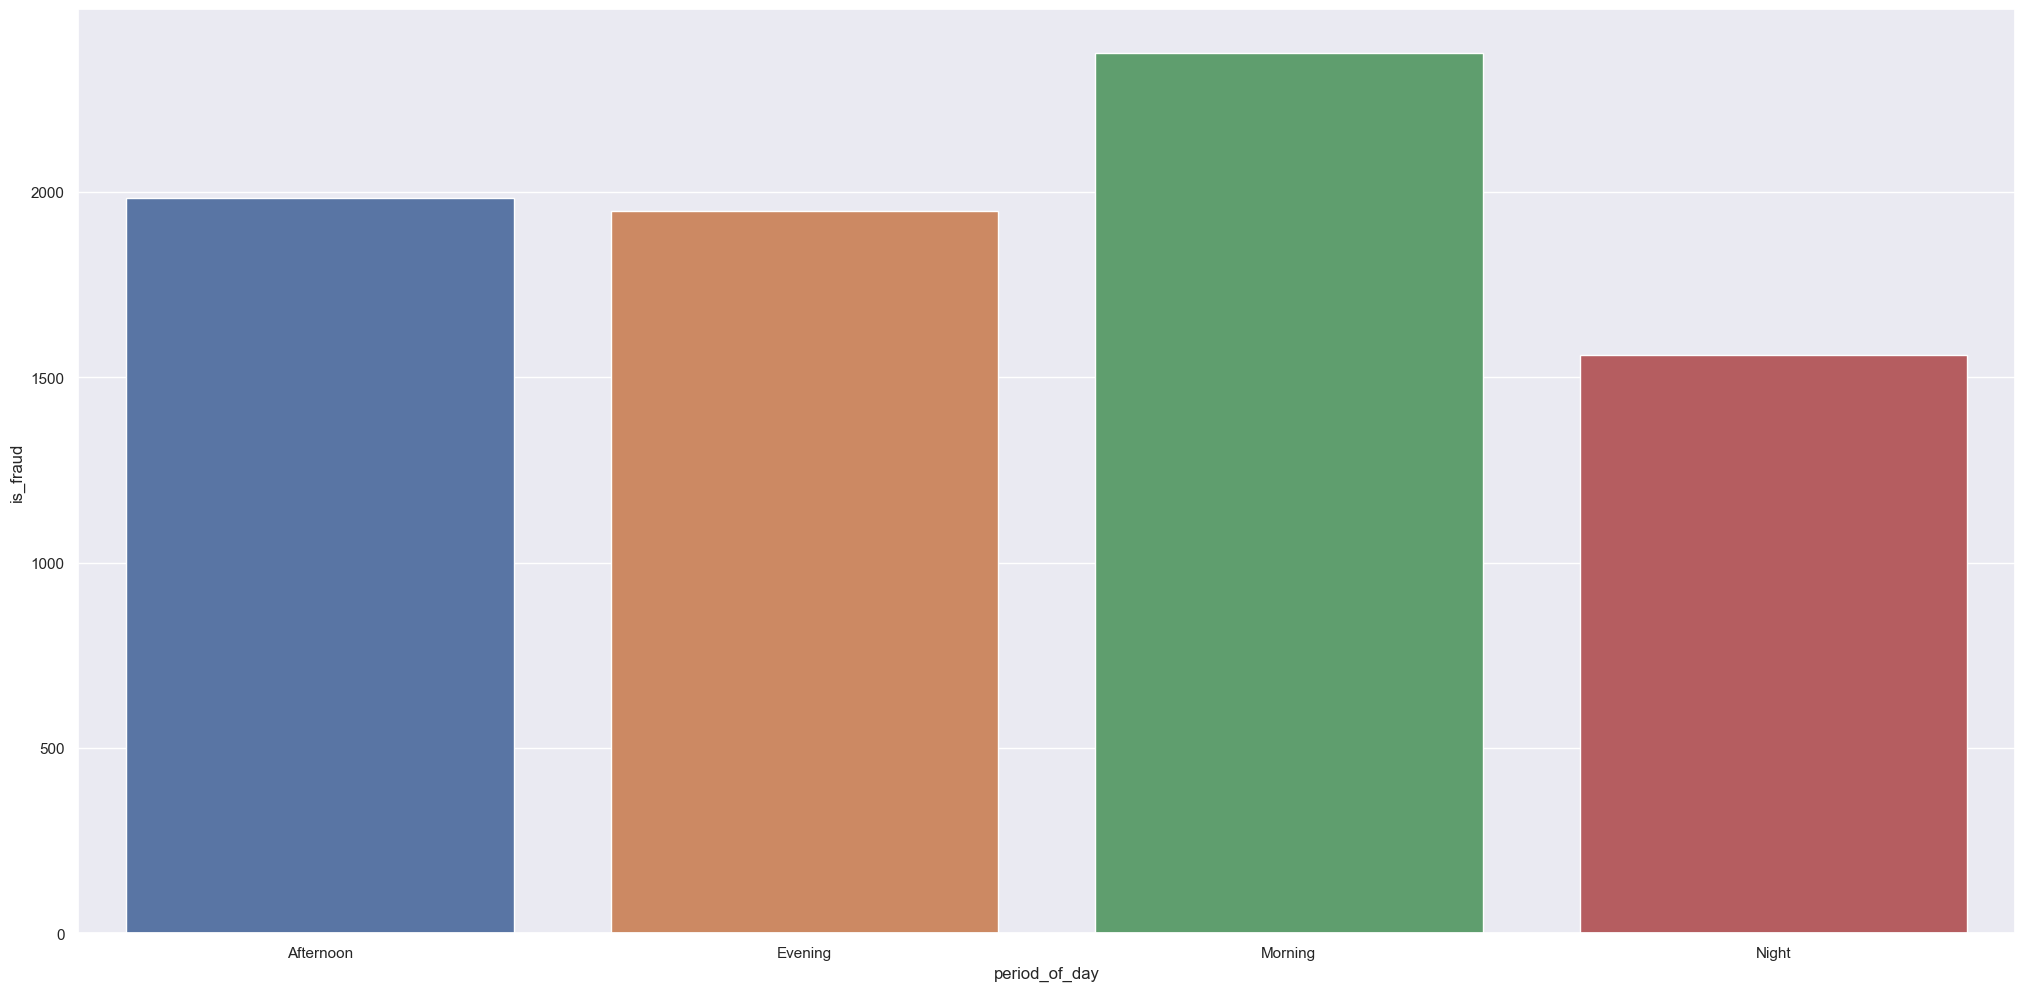

In [44]:
# Periodo do dia que mais ocorrem fraudes

aux1 = df4[['period_of_day', 'is_fraud']].groupby('period_of_day').sum().reset_index()

sns.barplot( x='period_of_day', y='is_fraud', data=aux1, hue='period_of_day')

In [45]:
df4.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night
9,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night
10,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night
15,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night


In [46]:
# Quantidade de transações fraudulentas no qual o total enviado é igual ao valor total da conta
aux2 = df4[df4['amount'] == df4['oldbalance_org']]

aux2.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0,1,1,Night
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0,1,1,Night
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0,1,1,Night
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0,1,1,Night
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0,1,1,Night


In [47]:
# Quantidade de transações válidas: 4196921
# Quantidade de transações fraudulentas: 7869
# Quantidade de transações com flag de fraudulentas: 12

In [48]:
aux2.shape

(7836, 14)

In [49]:
# As transações que são fraudes, geralmente são aquelas transações que "limpam" o valor da conta do cliente.

In [50]:
# Não existe clientes que fizeram mais de uma transação fraudulenta
fraude_por_cliente = df4[df4['is_fraud'] == 1].groupby('name_orig').size().reset_index(name='fraude_total')

In [51]:
df_fraud_aux = df4.merge(fraude_por_cliente, on='name_orig', how='left')

In [52]:
df_fraud_aux['fraude_total'] = df_fraud_aux['fraude_total'].fillna(0)
df_fraud_aux.head()

,step,type,amount,name_orig,oldbalance_org,newbalance_orig,name_dest,oldbalance_dest,newbalance_dest,is_fraud,is_flagged_fraud,day,hora,period_of_day,fraude_total
0,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.00,1,0,1,1,Night,1.0
1,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.00,1,0,1,1,Night,1.0
2,1,DEBIT,5337.77,C712410124,41720.0,36382.23,C195600860,41898.0,40348.79,0,0,1,1,Night,0.0
3,1,DEBIT,9644.94,C1900366749,4465.0,0.00,C997608398,10845.0,157982.12,0,0,1,1,Night,0.0
4,1,CASH_OUT,229133.94,C905080434,15325.0,0.00,C476402209,5083.0,51513.44,0,0,1,1,Night,0.0


<Axes: xlabel='fraude_total', ylabel='count'>

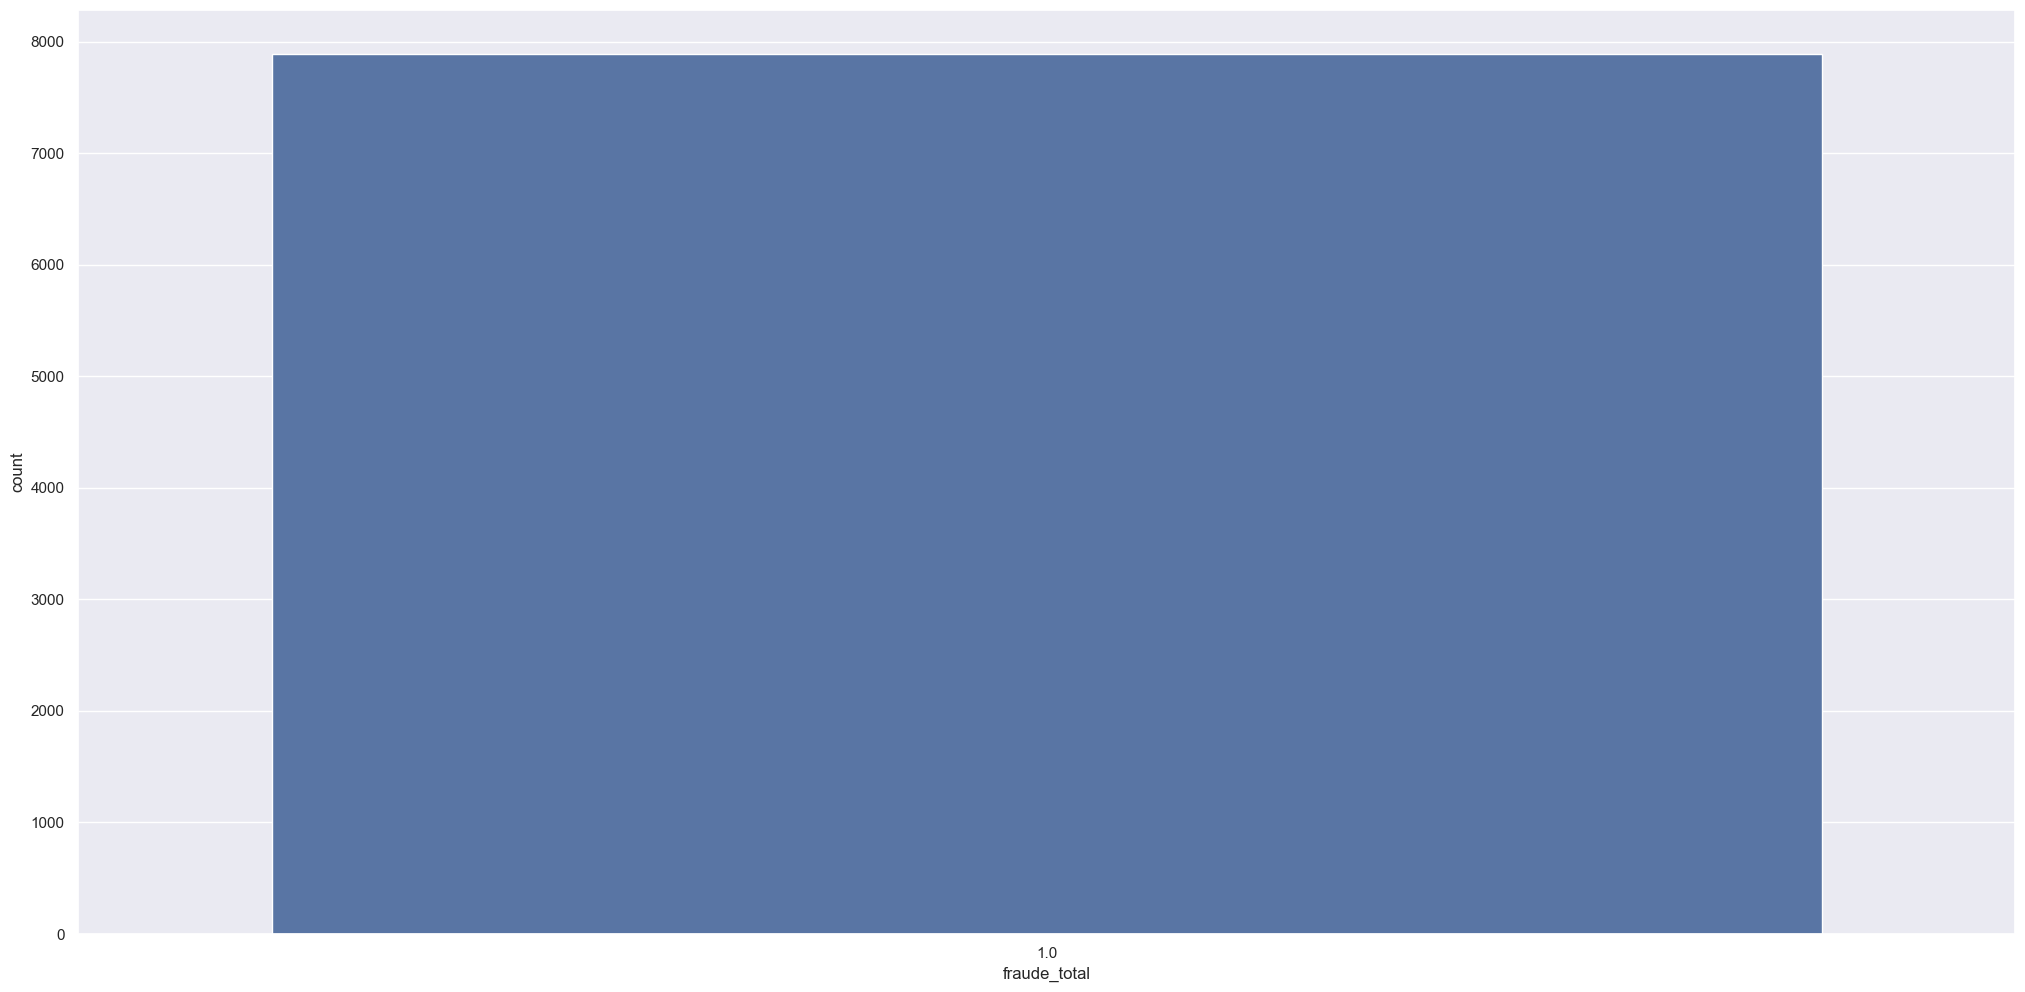

In [53]:

sns.countplot(data=df_fraud_aux[df_fraud_aux['fraude_total'] > 0], x='fraude_total')

## 4.3 Análise Multivariada

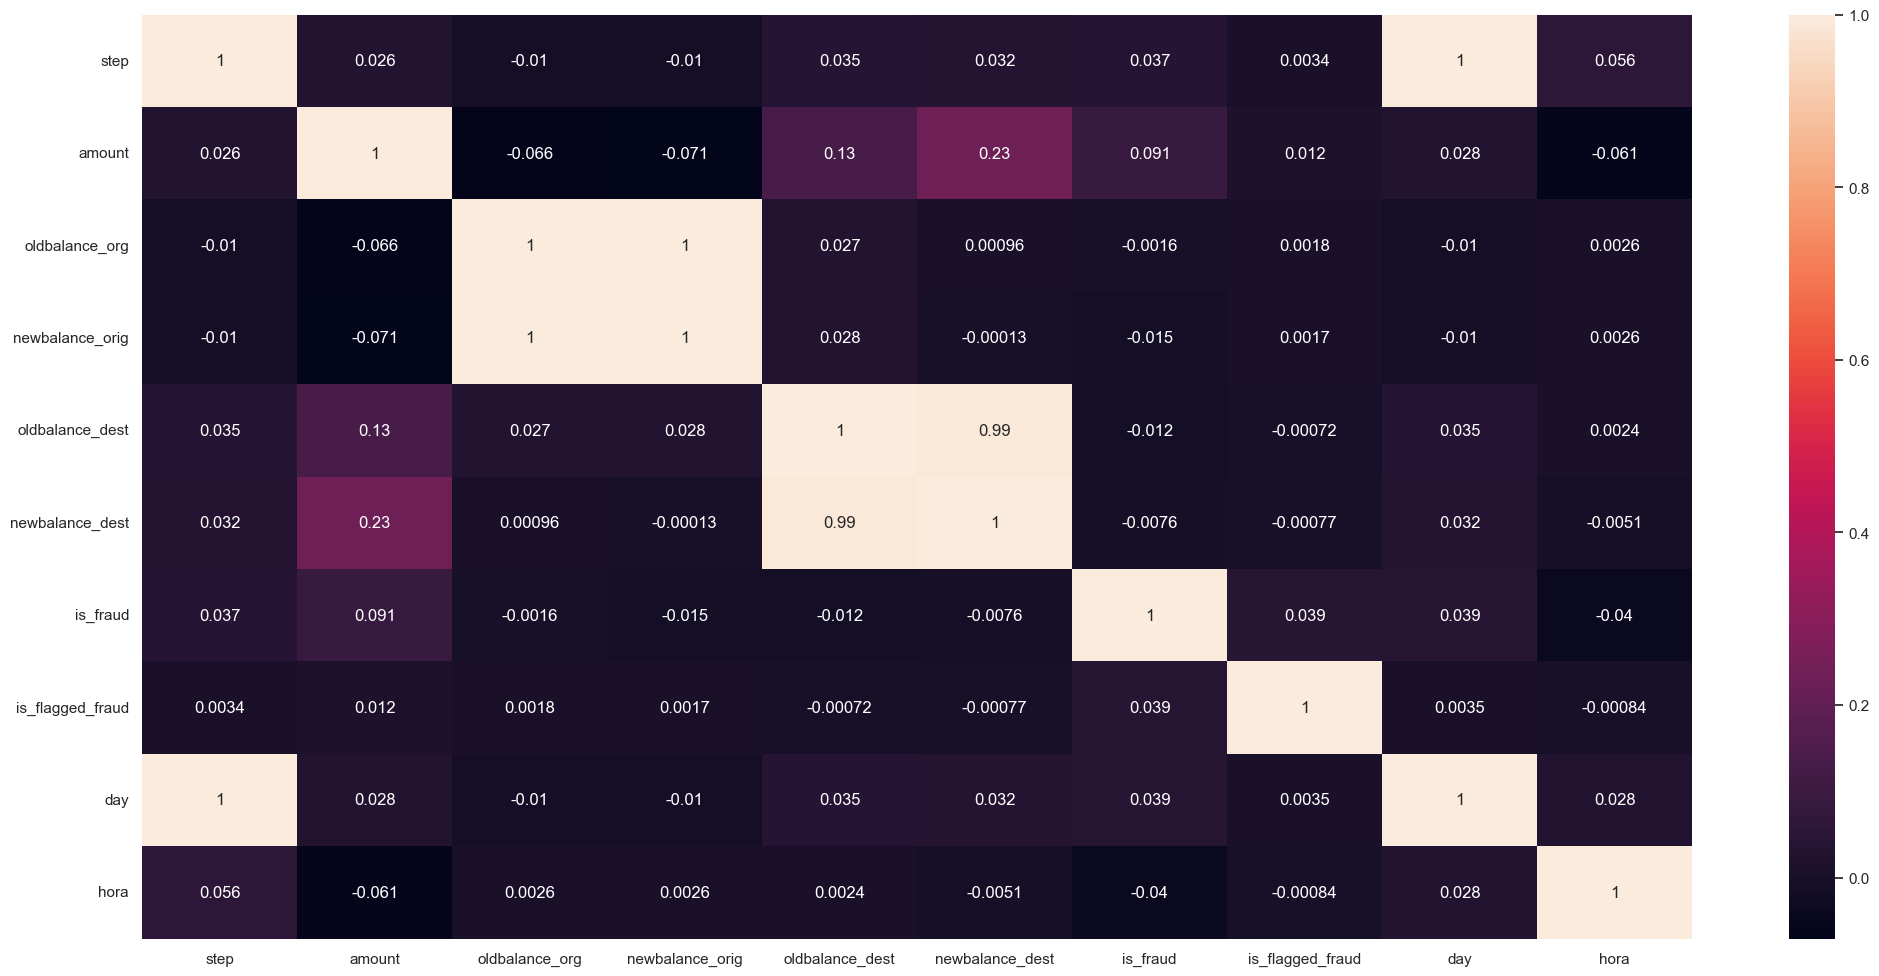

In [54]:
correlation = num_attributes.corr(method='pearson')
sns.heatmap(correlation, annot=True);

# 5.0 Data Preparation

In [55]:
df5 = df4.copy()

## 5.1 Transformation

In [56]:
# 0 => $0.1
eps = 0.001 

df5['amount'] = np.log(df5.pop('amount')+eps)
df5['oldbalance_org'] = np.log(df5.pop('oldbalance_org')+eps)
df5['newbalance_orig'] = np.log(df5.pop('newbalance_orig')+eps)
df5['oldbalance_dest'] = np.log(df5.pop('oldbalance_dest')+eps)
df5['newbalance_dest'] = np.log(df5.pop('newbalance_dest')+eps)

### 5.1.1 Encoding

In [57]:
df5 = pd.get_dummies(df5, prefix=['type'], columns=['type'])

## 5.2 Train Test Validation Split

In [58]:
train, test = train_test_split(df5, test_size=0.2, random_state=42, stratify=df5['is_fraud'])
train, val = train_test_split(train, test_size=0.2, random_state=42, stratify=train['is_fraud'])

In [59]:
print("Distribuição original:")
print(df5['is_fraud'].value_counts(normalize=True))

print("\nDistribuição no treino:")
print(train['is_fraud'].value_counts(normalize=True))

print("\nDistribuição no teste:")
print(test['is_fraud'].value_counts(normalize=True))

print("\nDistribuição no teste:")
print(val['is_fraud'].value_counts(normalize=True))

Distribuição original:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição no treino:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64

Distribuição no teste:
is_fraud
0    0.998128
1    0.001872
Name: proportion, dtype: float64

Distribuição no teste:
is_fraud
0    0.998129
1    0.001871
Name: proportion, dtype: float64


## 5.1 Transformation

### 5.1.1 One Hot Encoding

# 6.0 Feature Selection

In [60]:
df6 = train.copy()

In [61]:
df6_val = val.copy()

In [62]:
df6.columns

Index(['step', 'name_orig', 'name_dest', 'is_fraud', 'is_flagged_fraud', 'day',
       'hora', 'period_of_day', 'amount', 'oldbalance_org', 'newbalance_orig',
       'oldbalance_dest', 'newbalance_dest', 'type_CASH_IN', 'type_CASH_OUT',
       'type_DEBIT', 'type_TRANSFER'],
      dtype='object')

In [63]:
cols_drop = ['name_orig', 'name_dest', 'period_of_day', 'hora', 'day']
df6 = df6.drop(cols_drop, axis=1)
df6_val = df6_val.drop(cols_drop, axis=1)


In [64]:
X_train = df6.copy()
y_train = X_train['is_fraud']
X_train  = X_train.drop('is_fraud', axis=1)

X_train_val = df6_val.copy()
y_train_val = X_train_val['is_fraud']
X_train_val  = X_train_val.drop('is_fraud', axis=1)

# 7.0 Machine Learning Modeling

## 7.1 Random Forest Classifier

In [65]:
#define

rfc = en.RandomForestClassifier(max_depth=15, n_estimators=50)

# train

rfc.fit(X_train, y_train)

# performace 

y_hat_test = rfc.predict(X_train_val)

acc = mt.accuracy_score(y_train_val, y_hat_test)

precision = mt.precision_score(y_train_val, y_hat_test)

recall = mt.recall_score(y_train_val, y_hat_test)

f1_score = mt.f1_score(y_train_val, y_hat_test)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')


Acurácia: 0.9994871924455272
Precision: 0.9851380042462845
Recall: 0.7370929308975377
F1-Score: 0.8432530667878237


In [108]:
mt.balanced_accuracy_score(y_train_val,y_hat_test)

np.float64(0.7946433202638437)

In [68]:
scores = cross_validate(rfc, X_train_val, y_train_val, scoring='balanced_accuracy')

In [86]:
scores

{'fit_time': array([72.33185649, 73.03589106, 72.73442721, 71.45840883, 71.09779048]),
 'score_time': array([0.47937894, 0.44715476, 0.43013787, 0.41022897, 0.4187727 ]),
 'test_score': array([0.86505703, 0.86705977, 0.88444726, 0.87499628, 0.85116442])}

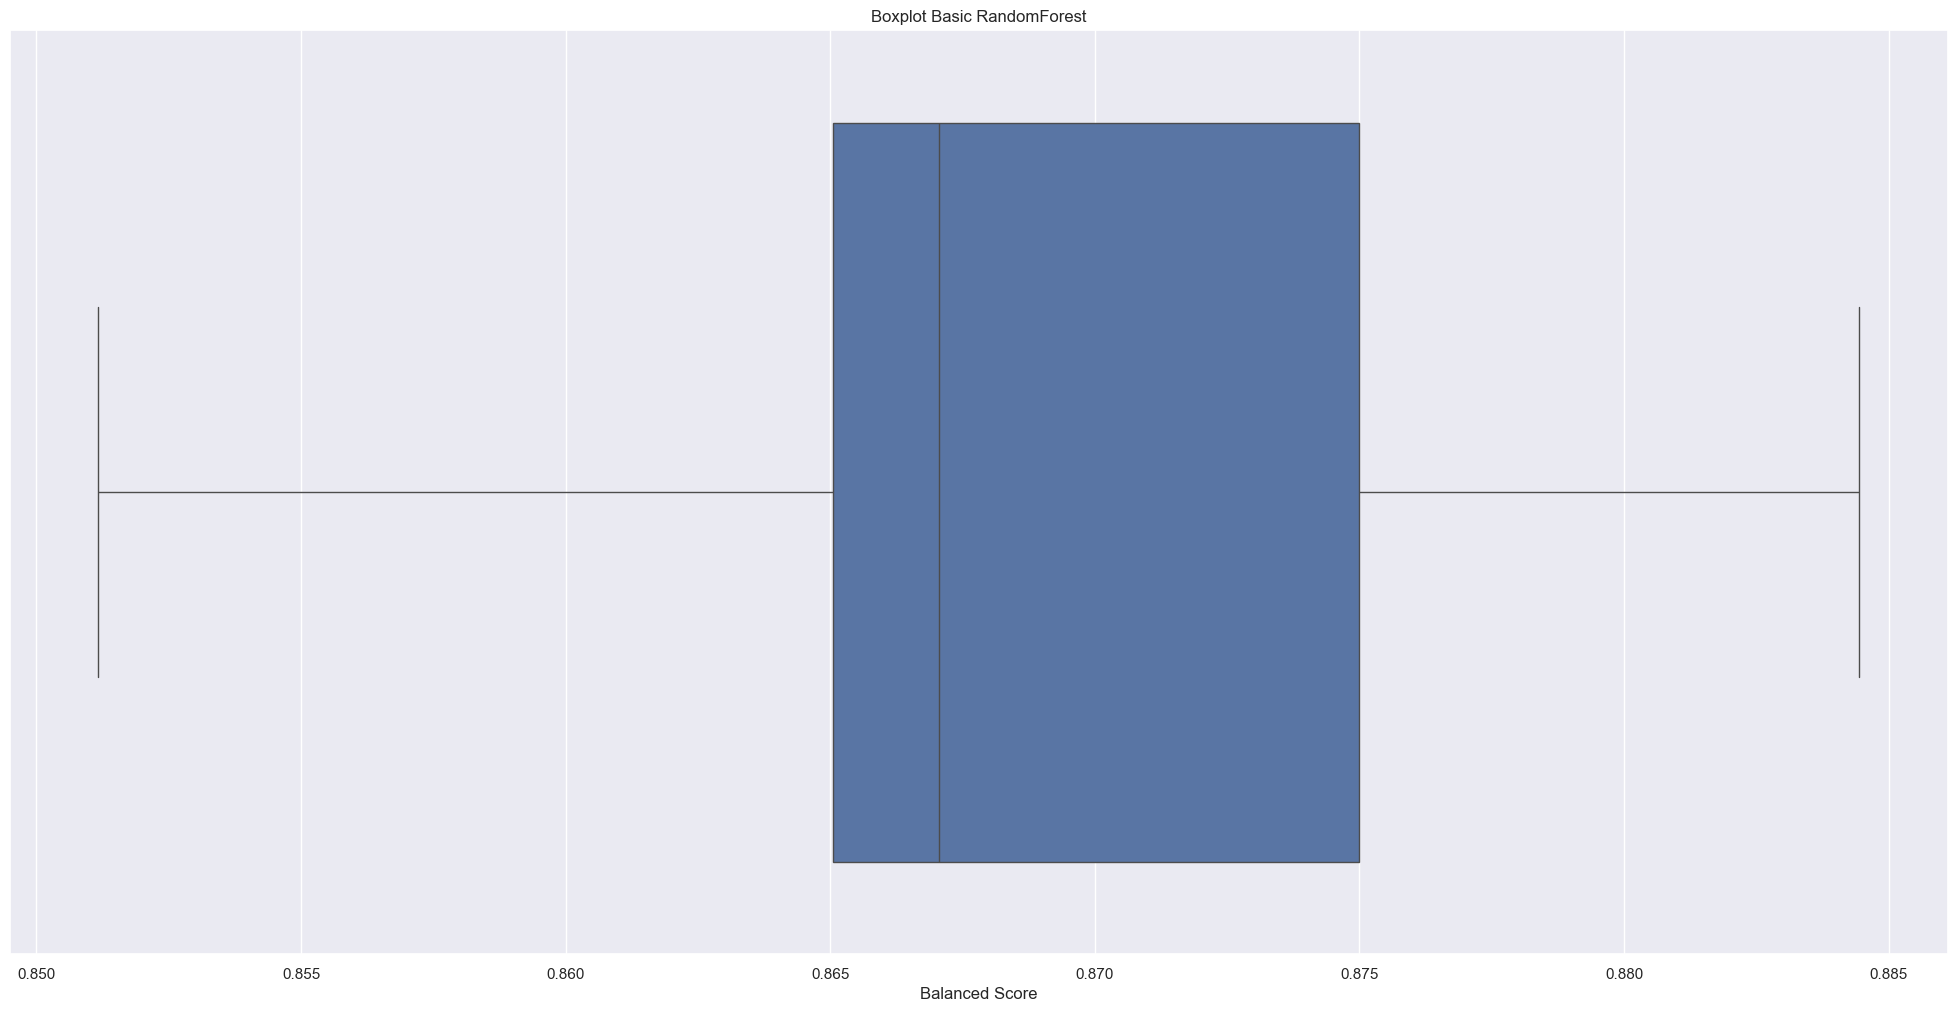

In [73]:
# Cria o boxplot para test_score
sns.boxplot(x=scores['test_score'])
plt.title('Boxplot Basic RandomForest')
plt.xlabel('Balanced Score')
plt.show()

### Random Forest Tunned

In [96]:
rf_tunned = TunedThresholdClassifierCV(rfc, scoring="balanced_accuracy").fit(X_train, y_train)



In [97]:
print(f"Cut-off point found at {rf_tunned.best_threshold_:.3f}")

Cut-off point found at 0.010


In [101]:
yhat_tunned = rfc.predict_proba(X_train_val)

In [ ]:
yhat_tunned = yhat_tunned[:,1]
th = 0.010
yhat_tunned_a = [1 if i > th else 0 for i in yhat_tunned]

In [106]:
acc = mt.accuracy_score(y_train_val, yhat_tunned_a)

precision = mt.precision_score(y_train_val, yhat_tunned_a)

recall = mt.recall_score(y_train_val, yhat_tunned_a)

f1_score = mt.f1_score(y_train_val, yhat_tunned_a)

print(f'Acurácia: {acc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1-Score: {f1_score}')

Acurácia: 0.9946831518192777
Precision: 0.25053809728798965
Recall: 0.9245432883240667
F1-Score: 0.3942421676545301


In [107]:
mt.balanced_accuracy_score(y_train_val,yhat_tunned_a)

np.float64(0.9596789721462122)

In [113]:
mt.confusion_matrix(y_train_val,y_hat_test)

array([[671461,     47],
       [   517,    742]])

In [112]:
mt.confusion_matrix(y_train_val,yhat_tunned_a)

array([[668026,   3482],
       [    95,   1164]])

In [ ]:
scores_rfc_tunned = cross_validate(rfc, X_train_val, y_train_val, scoring='balanced_accuracy')

In [74]:
# acc = mt.accuracy_score(y_train_val, yhat_test)

# precision = mt.precision_score(y_train_val, yhat_test)

# recall = mt.recall_score(y_train_val, yhat_test)

# f1_score = mt.f1_score(y_train_val, yhat_test)

# print(f'Acurácia: {acc}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1-Score: {f1_score}')

In [ ]:
# fpr, tpr, threshold = mt.roc_curve(y_train_val, y_hat_test)

In [75]:
# plt.plot (fpr, tpr, marker='.')
# plt.xlabel ('False Positive Rate')
# plt.ylabel ('True Positive Rate')

In [76]:
# plt.plot (threshold, tpr, 'b--', label='TPR')
# plt.plot (threshold, 1-fpr, 'g--', label='FPR')
# plt.vlines( 0.65, 0, 1, color='r', linestyles='--')
# plt.legend()

## 7.2 Logistic Regression

In [119]:
# definition

lr = lm.LogisticRegression(max_iter=1000)

# training (fit)

lr.fit(X_train, y_train)

# performace

y_hat_test_logistic = lr.predict_proba(X_train_val)

# acc = mt.accuracy_score(y_train_val, y_hat_test_logistic)
# precision = mt.precision_score(y_train_val, y_hat_test_logistic)
# recall = mt.recall_score(y_train_val, y_hat_test_logistic)
# f1_score = mt.f1_score(y_train_val, y_hat_test_logistic)

# print(f'Acurácia: {acc}')
# print(f'Precision: {precision}')
# print(f'Recall: {recall}')
# print(f'F1-Score: {f1_score}')

In [79]:
scores_logistic = cross_validate(lr, X_train_val, y_train_val, scoring='balanced_accuracy')

In [85]:
scores_logistic

{'fit_time': array([6.70162344, 6.33404756, 8.46965575, 7.00231814, 5.97327423]),
 'score_time': array([0.03200841, 0.02055264, 0.02044344, 0.02846766, 0.02600718]),
 'test_score': array([0.79560886, 0.76186753, 0.78881111, 0.77973584, 0.75988341])}

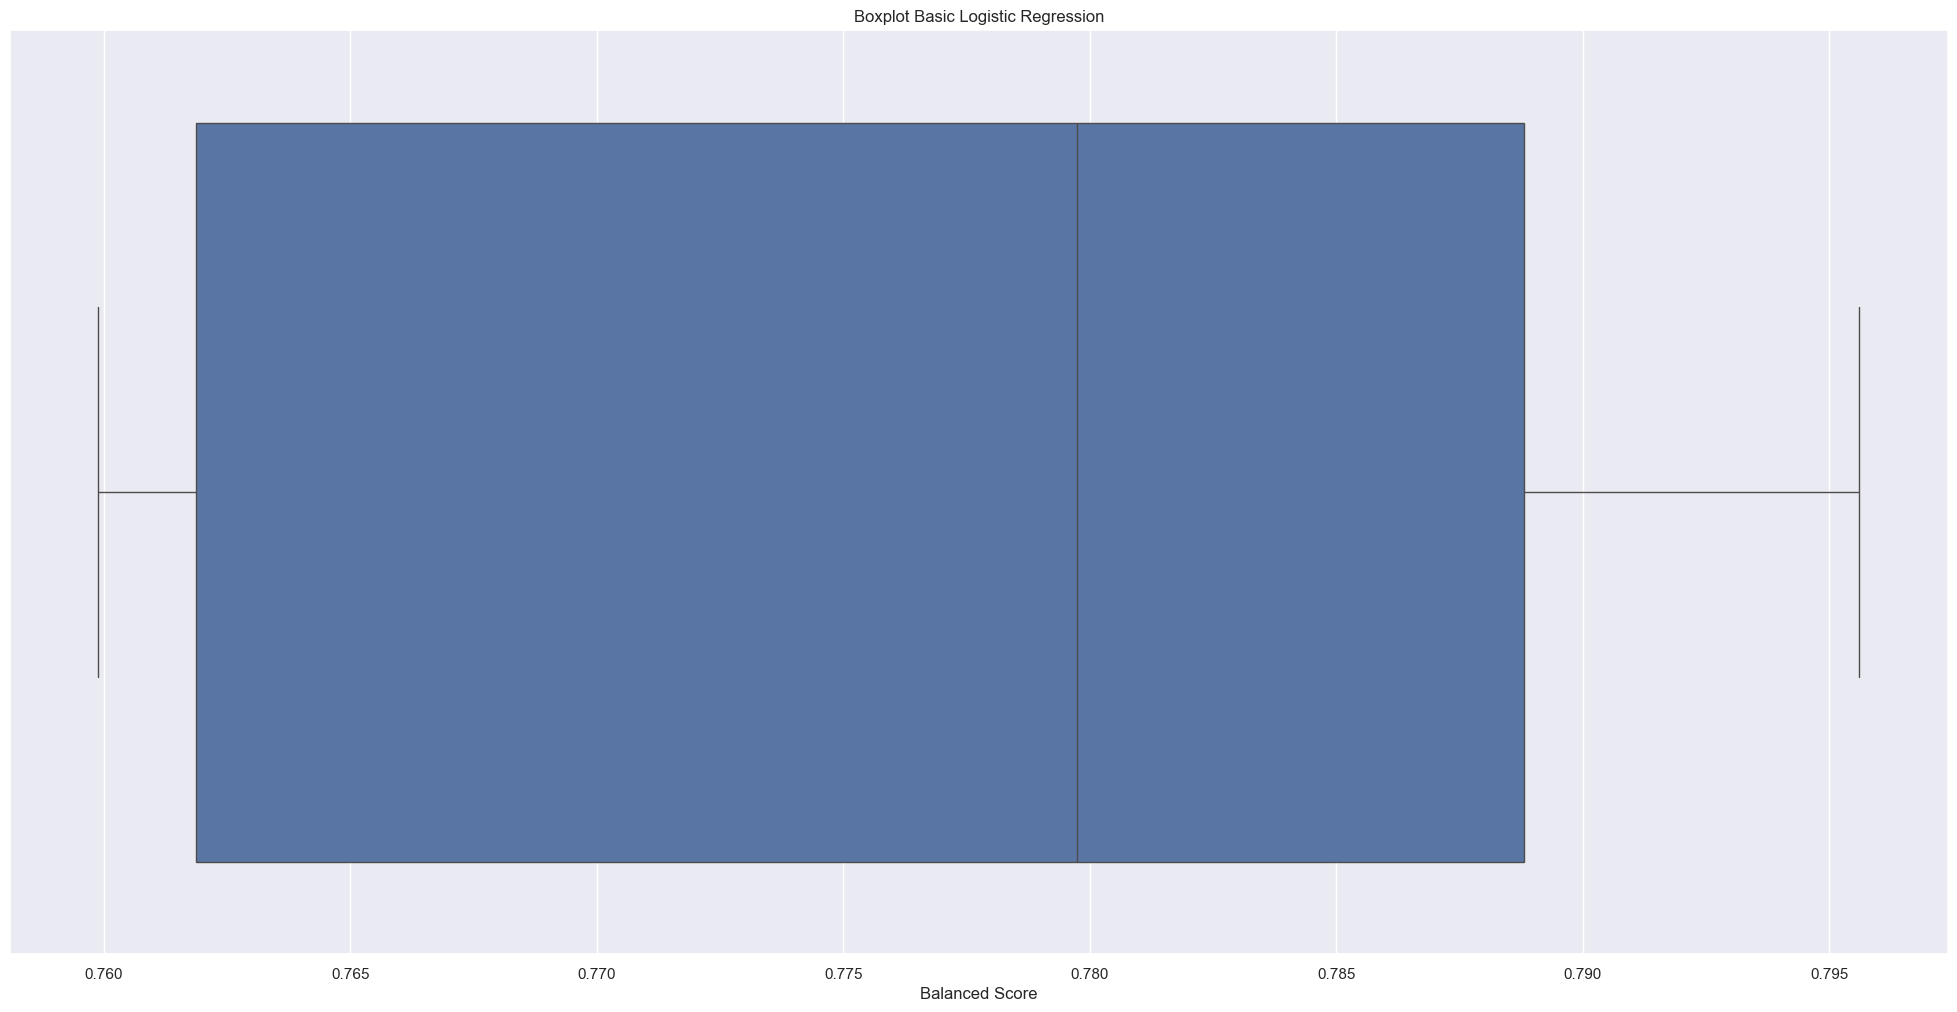

In [81]:
# Cria o boxplot para test_score
sns.boxplot(x=scores_logistic['test_score'])
plt.title('Boxplot Basic Logistic Regression')
plt.xlabel('Balanced Score')
plt.show()

In [116]:
lr_tunned = TunedThresholdClassifierCV(lr, scoring="balanced_accuracy").fit(X_train, y_train)

In [117]:
print(f"Cut-off point found at {lr_tunned.best_threshold_:.3f}")

Cut-off point found at 0.010


In [120]:
y_hat_test_logistic = y_hat_test_logistic[:,1]
th = 0.010
yhat_tunned_lr = [1 if i > th else 0 for i in y_hat_test_logistic]

In [122]:
mt.balanced_accuracy_score(y_train_val,yhat_tunned_lr)

np.float64(0.9724617516238853)

In [123]:
mt.confusion_matrix(y_train_val, yhat_tunned_lr)

array([[661192,  10316],
       [    50,   1209]])

In [ ]:
# fpr, tpr, threshold = mt.roc_curve(y_train_val, y_hat_test)

In [82]:
# plt.plot (fpr, tpr, marker='.')
# plt.xlabel ('False Positive Rate')
# plt.ylabel ('True Positive Rate')

In [83]:
# plt.plot (threshold, tpr, 'b--', label='TPR')
# plt.plot (threshold, 1-fpr, 'g--', label='FPR')
# plt.vlines( 0.65, 0, 1, color='r', linestyles='--')
# plt.legend()

In [87]:
df_resultados = pd.DataFrame({
    'Modelo': ['RandomForest'] * len(scores['test_score']) + ['LogisticRegression'] * len(scores_logistic['test_score']),
    'Test Score': list(scores['test_score']) + list(scores_logistic['test_score'])
})

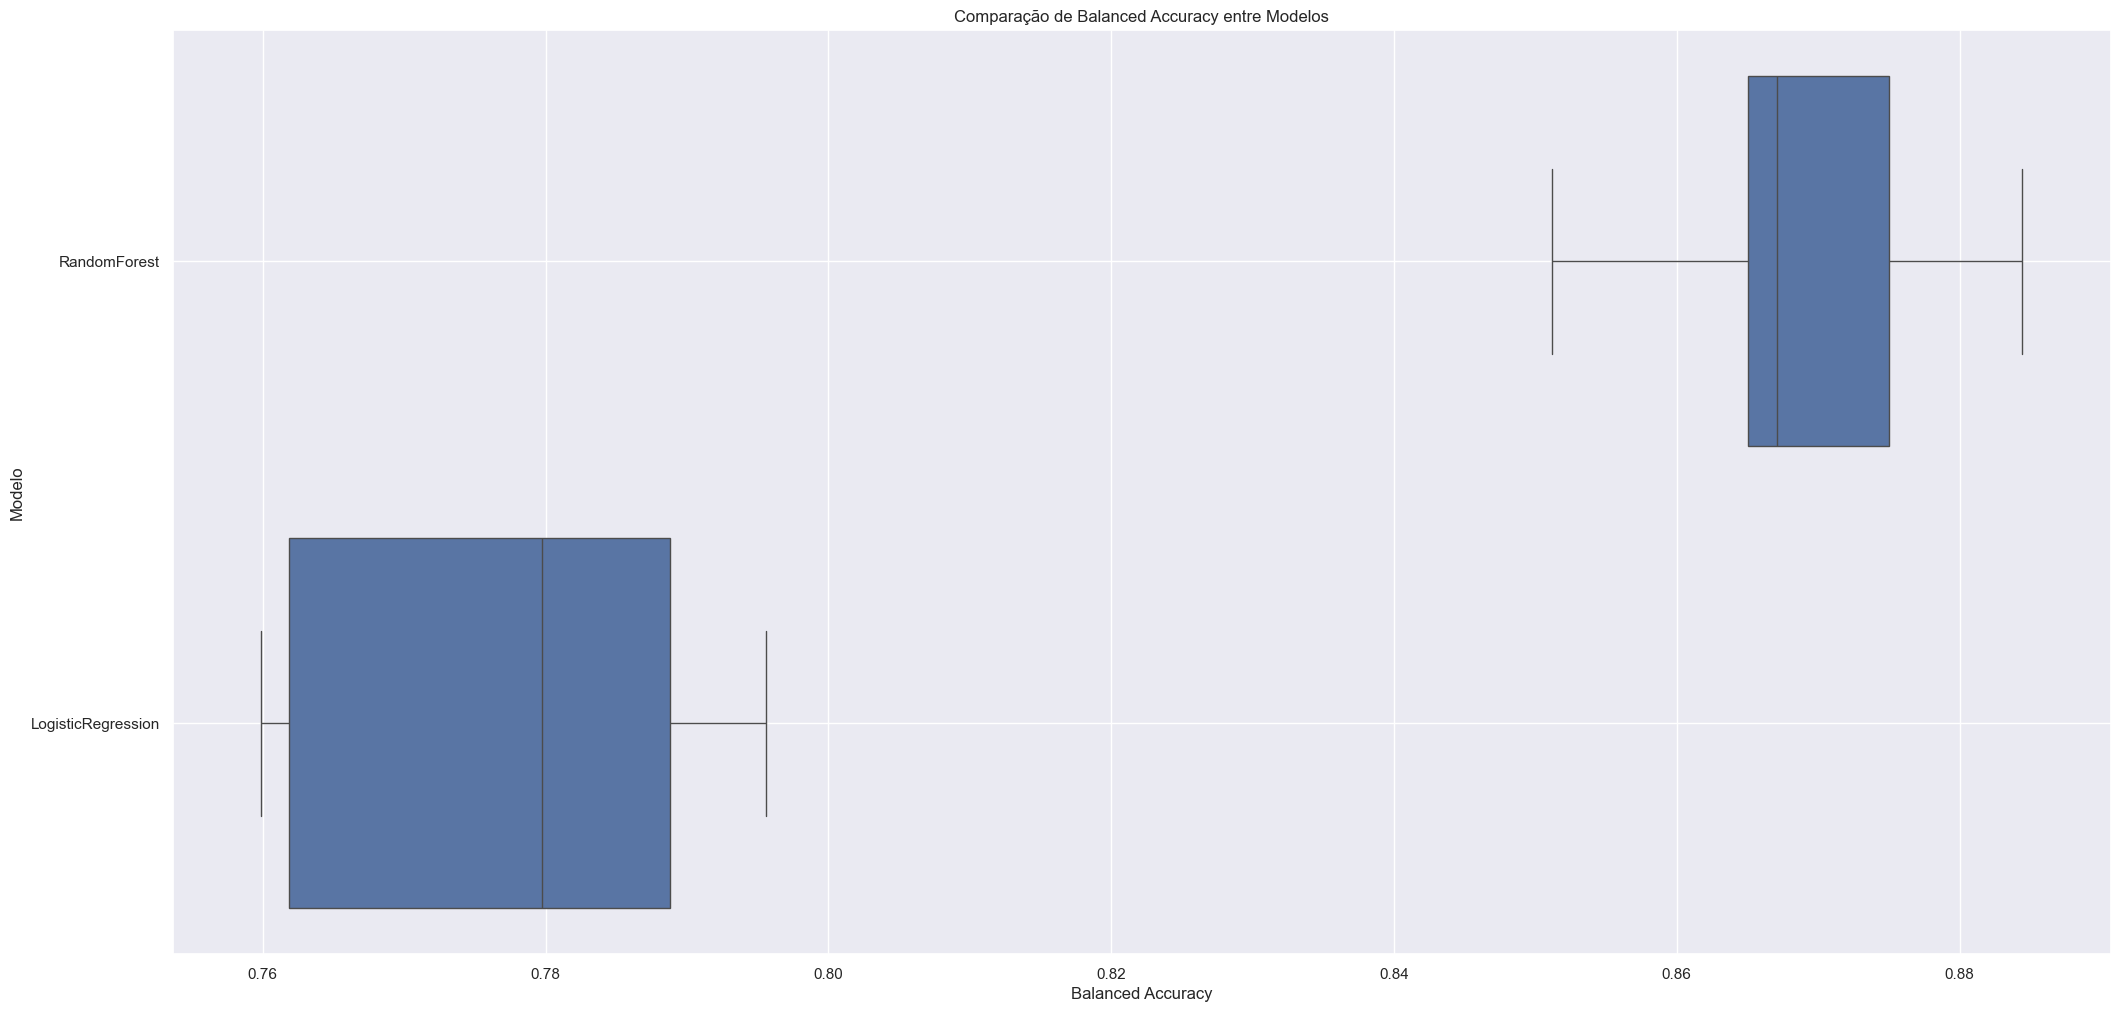

In [92]:
sns.boxplot(x='Test Score', y='Modelo', data=df_resultados)
plt.title('Comparação de Balanced Accuracy entre Modelos')
plt.xlabel('Balanced Accuracy')
plt.grid(True)
plt.show()

# 8.0 Hyperparameter Fine Tunnig

# 9.0 Final Model